In [1]:
import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from shapely import contains_xy
from shapely import Polygon

In [2]:
def point_in_polygon(lon, lat, polygon):
    point = Point(lon, lat)
    return polygon.contains(point)

In [3]:
# Define a transformation to ensure the polygon's CRS matches
def transform_polygon(polygon, src_crs='epsg:4326', tgt_crs='epsg:4326'):
    # Transform the polygon to match the DataArray CRS if needed
    proj = pyproj.Transformer.from_proj(pyproj.Proj(src_crs), pyproj.Proj(tgt_crs), always_xy=True)
    return transform(lambda x, y: proj.transform(x, y), polygon)

In [4]:
file='./Cuencas/NAEast.csv'
df=pd.read_csv(file)

In [5]:
demPolygon = Polygon(np.column_stack((df.lon, df.lat)))

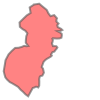

In [6]:
demPolygon

In [7]:
step = .25
longitude_space = np.arange(-180, 180 + step, step, dtype = float)
latitude_space = np.arange(-90, 90 + step, step, dtype = float)
lon_grid, lat_grid = np.meshgrid(longitude_space, latitude_space)


In [8]:
filesA = {'./Cuencas/NAEast.csv':1,
'./Cuencas/NAWest.csv':2,
'./Cuencas/NACaribe.csv':3,
'./Cuencas/SAEast.csv':4,
'./Cuencas/SAWest.csv':5,
'./Cuencas/SAEastNamibia.csv':6,
'./Cuencas/SAWestMalvinas.csv':7,
'./Cuencas/SouthAfrica.csv':8,
'./Cuencas/SACentralAntartica.csv':9,
'./Cuencas/SPEastAntartica.csv':10}

filesI={'./Cuencas/EastMadagascar.csv':11,
'./Cuencas/SouthMadagascar.csv':12,
'./Cuencas/NIWest.csv':13,
'./Cuencas/NICentral.csv':14,
'./Cuencas/NICentralEast.csv':15,
'./Cuencas/NIEast.csv':16,
#'./Cuencas/SACentralAntartica.csv',
#'./Cuencas/SouthAfrica.csv':27,
'./Cuencas/SouthAustralia.csv':17,
'./Cuencas/SIEastAntartica.csv':18}

filesP={'./Cuencas/NPWest.csv':21,
'./Cuencas/NPEast.csv':22,
'./Cuencas/NPEastEast.csv':23,
'./Cuencas/NPCentral.csv':24,
'./Cuencas/SPCentral.csv':25,
'./Cuencas/SPWestCentral.csv':26,
'./Cuencas/SPEastAustralia.csv':27,
#'./Cuencas/SIEastAntartica.csv':,
'./Cuencas/SPWest.csv':28,
'./Cuencas/SPEastNorth.csv':29,
'./Cuencas/SPEastChile.csv':30,
#'./Cuencas/SouthAustralia.csv':21,
#'./Cuencas/SPEastAntartica.csv':21
}


In [20]:
Z = np.zeros(lon_grid.shape)
Z=Z*np.nan

for file, vZ in filesA.items():
    df=pd.read_csv(file)
    demPolygon = Polygon(np.column_stack((df.lon, df.lat)))
    mask = contains_xy(demPolygon, lon_grid, lat_grid)
    Z[mask] = vZ

for file, vZ in filesA.items():
    df=pd.read_csv(file)
    demPolygon = Polygon(np.column_stack((df.lon-360, df.lat)))
    mask = contains_xy(demPolygon, lon_grid, lat_grid)
    Z[mask] = vZ


for file, vZ in filesI.items():
    df=pd.read_csv(file)
    demPolygon = Polygon(np.column_stack((df.lon, df.lat)))
    mask = contains_xy(demPolygon, lon_grid, lat_grid)
    Z[mask] = vZ    

for file, vZ in filesP.items():
    df=pd.read_csv(file)
    demPolygon = Polygon(np.column_stack((df.lon-360, df.lat)))
    mask = contains_xy(demPolygon, lon_grid, lat_grid)
    Z[mask] = vZ       

for file, vZ in filesP.items():
    df=pd.read_csv(file)
    demPolygon = Polygon(np.column_stack((df.lon, df.lat)))
    mask = contains_xy(demPolygon, lon_grid, lat_grid)
    Z[mask] = vZ   

In [11]:

Z_filled = Z.copy()

for j in range(1, Z.shape[1]-1):  # evitamos bordes
    nan_mask = np.isnan(Z[:, j])
    
    # NaN con vecinos válidos a izquierda y derecha
    valid_left  = ~np.isnan(Z[:, j-1])
    valid_right = ~np.isnan(Z[:, j+1])
    
    # solo NaNs aislados
    mask = nan_mask & valid_left & valid_right
    
    # rellenar (elige cómo)
    Z_filled[mask, j] = Z[mask, j-1]

Z=Z_filled   

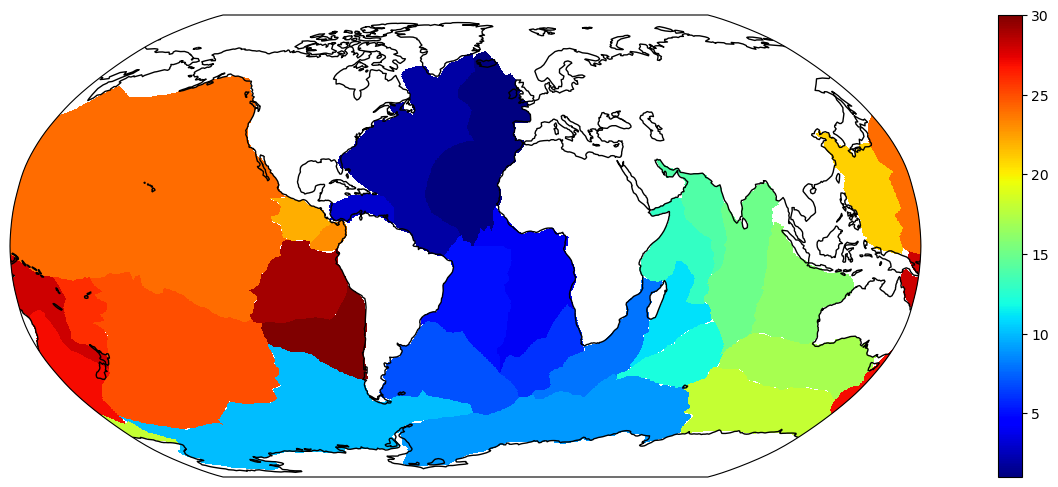

In [21]:
fig, ax = plt.subplots(figsize=(20,6),
    subplot_kw={'projection': ccrs.Robinson(central_longitude=-30)})

ax.set_global()
ax.coastlines()
pcm = ax.pcolormesh(lon_grid, lat_grid, Z,transform=ccrs.PlateCarree(),
                    cmap='jet')

ax.add_feature(cfeature.LAND, facecolor='white')

cbar = fig.colorbar(pcm, ax=ax)

(array([3674., 2487., 4547., 4357., 1814., 3286.,  653., 7563., 4049.,
        1941.]),
 array([ 1. ,  3.9,  6.8,  9.7, 12.6, 15.5, 18.4, 21.3, 24.2, 27.1, 30. ]),
 <BarContainer object of 10 artists>)

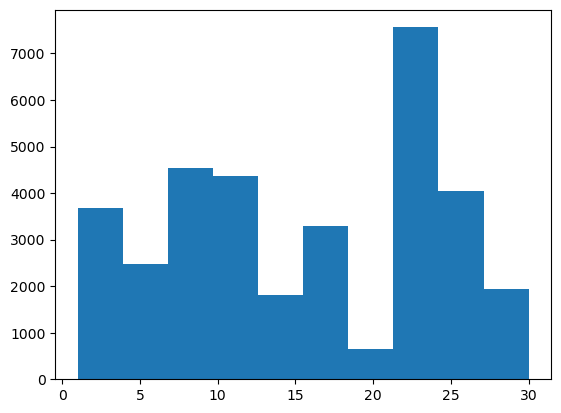

In [33]:
plt.hist(Z.flatten())

In [35]:
mask_nan = np.isnan(Z)

In [36]:
mask_nan

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(181, 361))